<a href="https://colab.research.google.com/github/ShauryaPrakashVerma/Machine_Learning_Practice/blob/main/27_One_Hot_Encoding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## One Hot Encoding
 - used for nominal categorical data (data where the variables are not related to each other)

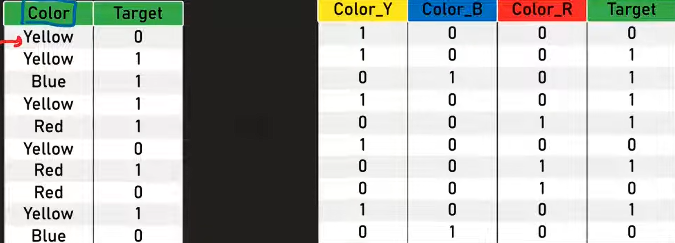

### Dummy variable Trap

In [ ]:
# we split the data into dummy varible table
# it gives rise to the problem of multicollinearilty

# multicollinearity: in machine learning the input columns should be independent of each other, but in this problem the column value can be predicted due to the dependency among the input columns.
# this is called the dummy variable trap

# to avoid this we drop one column i.e. if no of unique variables are 'n' then 'n-1' columns are enough to represent n variables.


In [ ]:
# splitting the variables into multiple columns increases dimentionality, but solves the problem.

### One shot encoding using most frequent categories
 - most frequent categories are kept while the least frequently used categories are combined together into another completely differnet categories

 - this significantly reduces the dimensionality of the problem


 -  the prerequisite of this approach is the assumption ---> that some categories are appearing very frequently while some are appearing very less frequently

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("cars.csv")

In [3]:
df.head()

,brand,km_driven,fuel,owner,selling_price
0,Maruti,145500,Diesel,First Owner,450000
1,Skoda,120000,Diesel,Second Owner,370000
2,Honda,140000,Petrol,Third Owner,158000
3,Hyundai,127000,Diesel,First Owner,225000
4,Maruti,120000,Petrol,First Owner,130000


In [4]:
df['brand'].value_counts()

,count
brand,
Maruti,2448
Hyundai,1415
Mahindra,772
Tata,734
Toyota,488
Honda,467
Ford,397
Chevrolet,230
Renault,228


In [5]:
df['fuel'].value_counts()

,count
fuel,
Diesel,4402
Petrol,3631
CNG,57
LPG,38


In [6]:
df['owner'].value_counts()

,count
owner,
First Owner,5289
Second Owner,2105
Third Owner,555
Fourth & Above Owner,174
Test Drive Car,5


## One Hot Enoding using Pandas

In [8]:
# pd.get_dummies(df, columns=['fuel', 'owner'])   mutilinearity problem present


pd.get_dummies(df, columns=['fuel', 'owner'], drop_first=True)   # multicollinearity problem solved

,brand,km_driven,selling_price,fuel_Diesel,fuel_LPG,fuel_Petrol,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,Maruti,145500,450000,True,False,False,False,False,False,False
1,Skoda,120000,370000,True,False,False,False,True,False,False
2,Honda,140000,158000,False,False,True,False,False,False,True
3,Hyundai,127000,225000,True,False,False,False,False,False,False
4,Maruti,120000,130000,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai,110000,320000,False,False,True,False,False,False,False
8124,Hyundai,119000,135000,True,False,False,True,False,False,False
8125,Maruti,120000,382000,True,False,False,False,False,False,False
8126,Tata,25000,290000,True,False,False,False,False,False,False


## OneHotEncoding using Sklearn

In [35]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(df.iloc[:,0:4], df.iloc[:,-1], test_size=0.2, random_state= 1)

In [36]:
from sklearn.preprocessing import OneHotEncoder

In [37]:
ohe = OneHotEncoder(drop='first')   # we only want to apply one hot encoding on owner and fuel columns

In [38]:
x_train_new = ohe.fit_transform(x_train[['fuel', 'owner']]).toarray()

In [39]:
x_test_new = ohe.transform(x_test[['fuel', 'owner']]).toarray()

In [40]:
np.hstack(x_train[['brand', 'km_driven']].values)

array(['Honda', 100000, 'Maruti', ..., 110000, 'Maruti', 65755],
      dtype=object)

## One hot encoding with top categories

In [42]:
counts = df['brand'].value_counts()

In [43]:
df['brand'].nunique()
threshold = 100

In [44]:
repl = counts[counts <= threshold ].index

In [45]:
pd.get_dummies(df['brand'].replace(repl, 'uncommon'))

,BMW,Chevrolet,Ford,Honda,Hyundai,Mahindra,Maruti,Renault,Skoda,Tata,Toyota,Volkswagen,uncommon
0,False,False,False,False,False,False,True,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,True,False,False,False,False
2,False,False,False,True,False,False,False,False,False,False,False,False,False
3,False,False,False,False,True,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8123,False,False,False,False,True,False,False,False,False,False,False,False,False
8124,False,False,False,False,True,False,False,False,False,False,False,False,False
8125,False,False,False,False,False,False,True,False,False,False,False,False,False
8126,False,False,False,False,False,False,False,False,False,True,False,False,False
